##### 1. Project Title & Objectives

##### Project: Payroll Analysis for Qinav Company

##### Required Analyses:
- Lowest salary;
- largest salary;
- Average and total spending on payroll;
- Total number of employees;
- Total Employees with received benefits;
- Percentage of Employees received benefits;
- The top 10 largest payroll expenditure by Jobs Title;
- Top 10 highest salaries;
- Salary distribution(Histogram and Boxplot);
- JobTitle % of total payroll;


##### Introduction Business Understanding
* This project aims to analyze payroll expenditure in order to identify the main cost centers, salary distribution and opportunities for workforce planning.

##### 2. import Libraries & Setup

In [146]:
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import locale as lc

# Set locale for US Dollar formatting
lc.setlocale(lc.LC_ALL, 'en_US.UTF-8')

# Set default visual style for charts
sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

# Create output directory
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

##### 3. Load and Preprocess Data

In [147]:
# Connect to the database
conn = sql.connect(r"output\salarios.sqlite")

# Define the query
query = '''SELECT * FROM salaries'''

# Load data into DataFrame
df = pd.read_sql(query, conn)

# Create a working copy
df_salaries = df.copy()

# Remove restriction on the display(Optional)
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

print("Data loaded successfully!")
print(f"Dataset shape: {df_salaries.shape}")

Data loaded successfully!
Dataset shape: (148654, 13)


##### 4. Data Cleaning

In [148]:
# Remove invalid rows ("Not provided")
# Why? These records represent invalid positions and
# may distort position-based analyses
df_salaries = df_salaries[~df_salaries["JobTitle"].str.contains("Not provided")]

# Remove columns
remove_columns = [
    
        "Notes",
        "BasePay",
        "OvertimePay",
        "Benefits",
        "Notes",
        "Agency",
        "Status",
        "OtherPay"
    
]
df_salaries = df_salaries.drop(columns=remove_columns,axis=1)

# Create received a bonus column:
df_salaries["ReceivedBenefits"] = df_salaries["TotalPayBenefits"].apply(lambda x: "Yes" if x != 0 else "No")

##### 5. Formatting Functions

In [149]:
# Format as US Dollar
def format_currency(value):
    return lc.currency(value, grouping=True, symbol=True)

# Format number with thousands separator
def format_with_thousands(value):
    return f"{value:,.2f}"

#### 6. Exploratory Data Analysis (EDA)

In [150]:
print("=== DATA STRUCTURE ===")
display(df_salaries.dtypes)

print("\n=== MISSING VALUES ===")
print(df_salaries.isnull().sum())

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df_salaries.describe())

print("\n=== FIRST 5 ROWS ===")
display(df_salaries.head())

=== DATA STRUCTURE ===


Id                    int64
EmployeeName         object
JobTitle             object
TotalPay            float64
TotalPayBenefits    float64
Year                  int64
ReceivedBenefits     object
dtype: object


=== MISSING VALUES ===
Id                  0
EmployeeName        0
JobTitle            0
TotalPay            0
TotalPayBenefits    0
Year                0
ReceivedBenefits    0
dtype: int64

=== DESCRIPTIVE STATISTICS ===


,Id,TotalPay,TotalPayBenefits,Year
count,148650.000000,148650.000000,148650.000000,148650.000000
mean,74325.500047,74770.333901,93695.075969,2012.522603
std,42911.703176,50516.196009,62792.497391,1.117526
min,1.000000,-618.130000,-618.130000,2011.000000
25%,37163.250000,36169.955000,44073.337500,2012.000000
50%,74325.500000,71427.240000,92406.020000,2013.000000
75%,111487.750000,105842.960000,132877.992500,2014.000000
max,148654.000000,567595.430000,567595.430000,2014.000000



=== FIRST 5 ROWS ===


,Id,EmployeeName,JobTitle,TotalPay,TotalPayBenefits,Year,ReceivedBenefits
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,567595.43,567595.43,2011,Yes
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),538909.28,538909.28,2011,Yes
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),335279.91,335279.91,2011,Yes
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,332343.61,332343.61,2011,Yes
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",326373.19,326373.19,2011,Yes


##### 7. Main Analysis & Results

In [151]:
# Total payroll metrics
lowestpayroll = df_salaries["TotalPayBenefits"].min()
largestpayroll = df_salaries["TotalPayBenefits"].max()
total_payroll = df_salaries["TotalPayBenefits"].sum()
avg_payroll = df_salaries["TotalPayBenefits"].mean()
median_payroll = df_salaries["TotalPayBenefits"].median()
total_employees = df_salaries["Id"].nunique()
total_employees_benefits = df_salaries.loc[df_salaries["ReceivedBenefits"]=="Yes"].shape[0]
percent_representation_employees_benefits = round((total_employees_benefits / total_employees) * 100,2)
salary_std = df_salaries["TotalPayBenefits"].std()
salary_q1 = df_salaries["TotalPayBenefits"].quantile(.25)
salary_q3 = df_salaries["TotalPayBenefits"].quantile(.75)
salary_iqr = salary_q3 - salary_q1
salary_p10 = df_salaries["TotalPayBenefits"].quantile(.10)
salary_p90 = df_salaries["TotalPayBenefits"].quantile(.90)

print("=== KEY PAYROLL METRICS ===")
print(f"Total Payroll Expenditure : {format_currency(total_payroll)}")
print(f"Total Number of Employees   : {format_with_thousands(total_employees)}")
print(f"Total Employees received Benefits : {format_with_thousands(total_employees_benefits)}")
print(f"Percentage of Employees with benefits : {percent_representation_employees_benefits}%")
print(f"Lowest Payroll Expenditure : {format_currency(lowestpayroll)}")
print(f"Largest Payroll Expenditure : {format_currency(largestpayroll)}")
print(f"Average Payroll cost per Employee: {format_currency(avg_payroll)}")
print(f"Median Payroll cost per Employee: {format_currency(median_payroll)}")
print(f"Standard deviation : {format_currency(salary_std)}")
print(f"1st Quartile : {format_currency(salary_q1)}")
print(f"3rd Quartitle : {format_currency(salary_q3)}")
print(f"IQR : {format_currency(salary_iqr)}")
print(f"The Bottom 10 % of Wages : {format_currency(salary_p10)}")
print(f"The Top 10 % of Salaries : {format_currency(salary_p90)}")

=== KEY PAYROLL METRICS ===
Total Payroll Expenditure : $13,927,773,042.81
Total Number of Employees   : 148,650.00
Total Employees received Benefits : 148,624.00
Percentage of Employees with benefits : 99.98%
Lowest Payroll Expenditure : ($618.13)
Largest Payroll Expenditure : $567,595.43
Average Payroll cost per Employee: $93,695.08
Median Payroll cost per Employee: $92,406.02
Standard deviation : $62,792.50
1st Quartile : $44,073.34
3rd Quartitle : $132,877.99
IQR : $88,804.65
The Bottom 10 % of Wages : $7,959.74
The Top 10 % of Salaries : $177,087.47


##### 8. The Top 10


=== THE TOP 10 LARGEST PAYROLL EXPENDITURE BY JOBS TITLE ===


,JobTitle,Total,Mean,Median,Min,Max
0,Transit Operator,"$647,781,613.95","$92,066.74","$106,136.56",$1.91,"$197,206.13"
1,Registered Nurse,"$566,569,738.88","$151,651.43","$164,730.73",$7.24,"$253,476.57"
2,Firefighter,"$431,972,718.89","$183,116.88","$190,999.49",$554.73,"$331,307.02"
3,Police Officer 3,"$406,090,319.74","$167,736.60","$174,415.29",($33.89),"$301,749.81"
4,Deputy Sheriff,"$276,251,014.41","$142,913.10","$144,141.17",$96.36,"$344,560.33"
5,Sergeant 3,"$212,733,914.28","$203,184.25","$204,387.96",$72.75,"$296,612.58"
6,Attorney (Civil/Criminal),"$202,201,425.31","$179,574.98","$201,333.32",$13.48,"$272,766.79"
7,Police Officer 2,"$195,579,360.93","$171,410.48","$172,727.53",$124.93,"$298,889.00"
8,Police Officer,"$183,158,895.79","$124,091.39","$142,099.54",$23.71,"$298,595.73"
9,Custodian,"$164,870,638.54","$68,184.71","$80,567.46",$0.00,"$110,855.05"


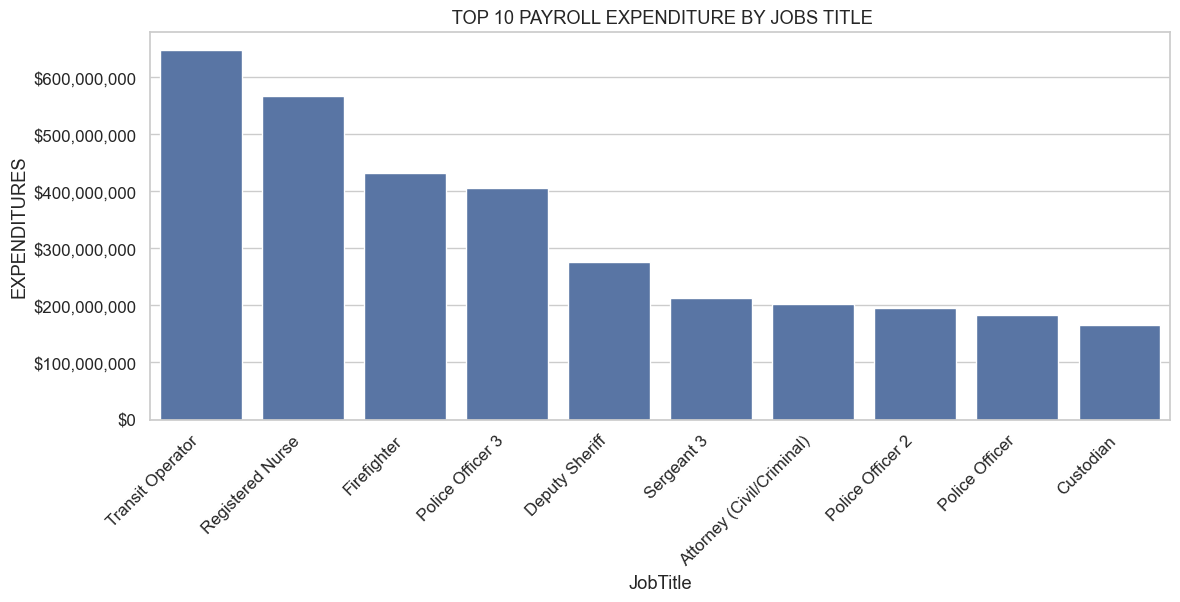

In [152]:
# Payroll by JobsTitle
print("\n=== THE TOP 10 LARGEST PAYROLL EXPENDITURE BY JOBS TITLE ===")

payroll_by_dept = (
    df_salaries[["TotalPayBenefits","JobTitle"]]
    .groupby("JobTitle")
    .agg(
        Total=("TotalPayBenefits","sum"),
        Mean=("TotalPayBenefits","mean"),
        Median=("TotalPayBenefits","median"),
        Min=("TotalPayBenefits","min"),
        Max=("TotalPayBenefits","max")
).round(2)
).sort_values(by="Total", ascending=False)

# Set default for bar charts
plt.figure(figsize=(12,6))

# Create a bar chart THE TOP 10 LARGEST PAYROLL EXPENDITURE BY JOBS TITLE
top10largespayroll = payroll_by_dept.nlargest(10,"Total") 
ax= sns.barplot(
    data = top10largespayroll.reset_index(),
    x="JobTitle",
    y="Total"
)

# Format a bar chart THE TOP 10 LARGEST PAYROLL EXPENDITURE BY JOBS TITLE
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.title(' TOP 10 PAYROLL EXPENDITURE BY JOBS TITLE')
plt.ylabel('EXPENDITURES')

# Format payroll_by_dept for dollar
top10largespayroll = top10largespayroll.map(format_currency)
# Reset Index
top10largespayroll = top10largespayroll.reset_index()

display(top10largespayroll)
plt.show()


=== THE TOP 10 HIGHEST AVERAGE SALARIES BY JOBTITLE ===


,JobTitle,AVG_Salaries
0,Chief Investment Officer,"$436,224.36"
1,Chief of Police,"$418,019.22"
2,"Chief, Fire Department","$417,435.10"
3,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,"$399,211.28"
4,"Gen Mgr, Public Trnsp Dept","$379,918.72"
5,Dep Chf of Dept (Fire Dept),"$365,548.28"
6,Mayor,"$362,551.66"
7,"Dep Dir for Investments, Ret","$355,731.26"
8,"Adm, SFGH Medical Center","$349,527.75"
9,Dept Head V,"$348,343.05"


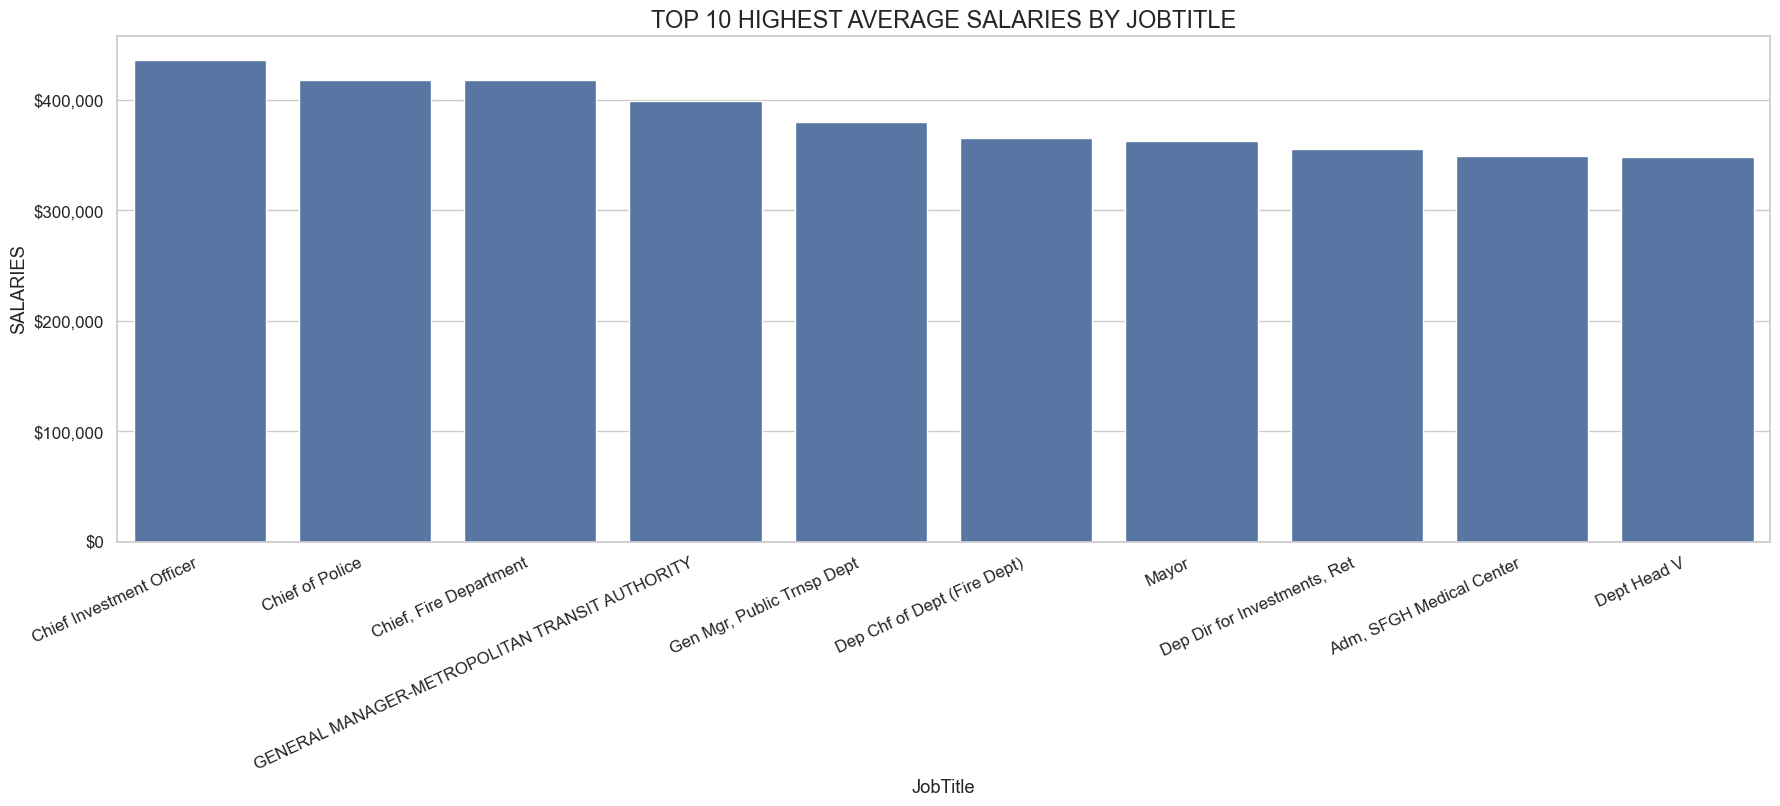

In [153]:
# Salaries by JobsTitle
print("\n=== THE TOP 10 HIGHEST AVERAGE SALARIES BY JOBTITLE ===")
largestsalaries = (
    df_salaries[["JobTitle", "TotalPayBenefits"]]
    .groupby("JobTitle")
    .agg(
        avg_salaries_jobstitle = ("TotalPayBenefits","median")
    )
    .sort_values(by="avg_salaries_jobstitle", ascending=False)
)

# Change the column name.
largestsalaries =  largestsalaries.rename(columns={"avg_salaries_jobstitle":"AVG_Salaries"})

# Create a DataFrame with the 10 highest salaries.
top10largessalaries = largestsalaries.nlargest(10, "AVG_Salaries")

# Set default for bar charts
plt.figure(figsize=(18,8))
# Create a bar chart of the 10 highest salaries by job title.
ax= sns.barplot(
    data=top10largessalaries.reset_index(),
    x="JobTitle",
    y="AVG_Salaries"
)

# Format a bar chart of the 10 highest salaries by job title.
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.title('TOP 10 HIGHEST AVERAGE SALARIES BY JOBTITLE',fontsize=17)
plt.ylabel('SALARIES')

# Format top10largessalaries for dollar
top10largessalaries["AVG_Salaries"] = top10largessalaries["AVG_Salaries"].map(format_currency)

# Reset Index 
top10largessalaries = top10largessalaries.reset_index()


display(top10largessalaries)
plt.show()

In [154]:
# Percentage of employees by position
employees_percent = (
    df_salaries[["Id","JobTitle"]]
    .groupby("JobTitle")
    .agg(
      Employees=("Id", "count"),
    )
    .sort_values(by="Employees", ascending=False)
    .reset_index()
)

employees_percent["Employee_%"] = (
    (employees_percent["Employees"] 
     / total_employees) * 100
).round(2)

print("\n=== PERCENTAGE OF EMPLOYEES BY POSITION ===")
display(employees_percent)


=== PERCENTAGE OF EMPLOYEES BY POSITION ===


,JobTitle,Employees,Employee_%
0,Transit Operator,7036,4.73
1,Special Nurse,4389,2.95
2,Registered Nurse,3736,2.51
3,Public Svc Aide-Public Works,2518,1.69
4,Police Officer 3,2421,1.63
...,...,...,...
2153,VICTIM & WITNESS TECHNICIAN,1,0.00
2154,WAREHOUSE WORKER,1,0.00
2155,LIEUTENANT II (POLICE DEPARTMENT),1,0.00
2156,Legislative Calendar Clerk,1,0.00


##### 9. Salary Distribution

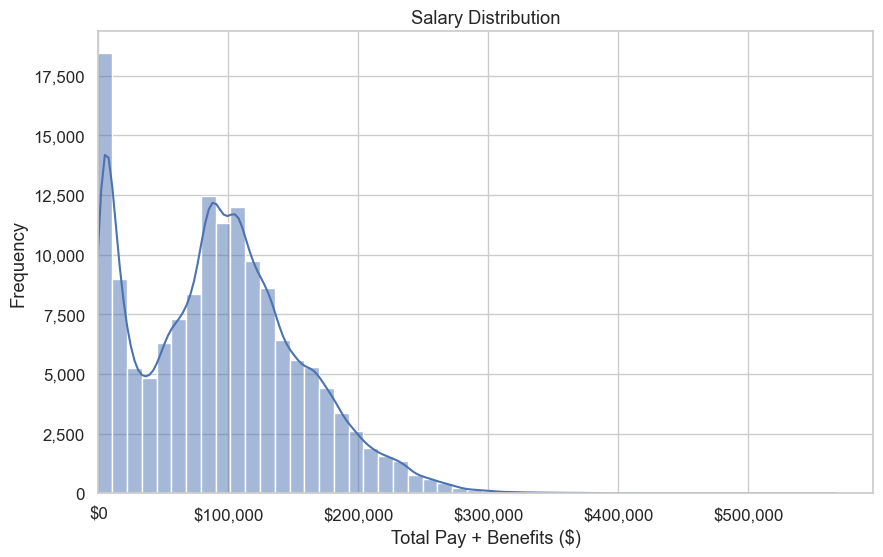

In [155]:
# Create a histogram chart
plt.figure(figsize=(10,6))
ax = sns.histplot(
    df_salaries['TotalPayBenefits'],
    bins=50,
    kde=True
)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
#plt.xticks(rotation=15) rotation(option)

plt.title('Salary Distribution')
plt.xlim(left=0)
plt.xlabel('Total Pay + Benefits ($)')
plt.ylabel('Frequency')
plt.show()

Business Insight:
* The salary distribution is right-skewed, 
  indicating that most employees are clustered 
  in mid-range pay bands while a smaller group 
  receives substantially higher compensation. 
* This pattern is common in organizations with 
  well-defined hierarchical structures and can 
  inform salary policy reviews or equity analyses.

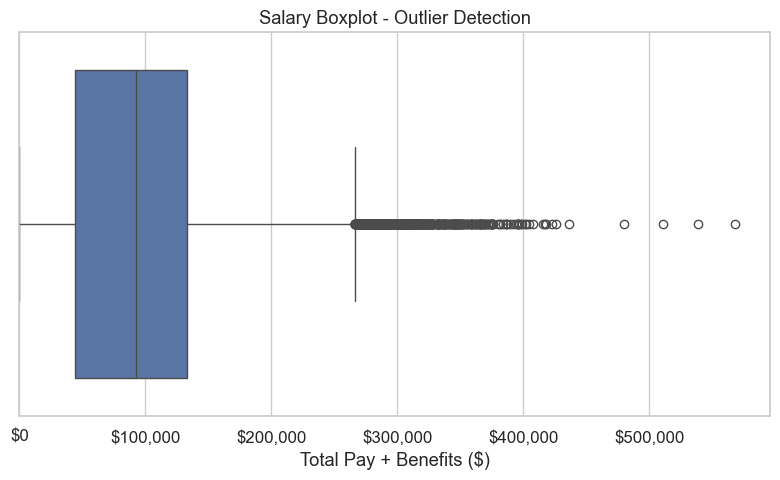

In [156]:
# Boxplot
plt.figure(figsize=(8,5))
ax = sns.boxplot(x=df_salaries['TotalPayBenefits'])

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
plt.title('Salary Boxplot - Outlier Detection')
plt.xlim(left=0)
plt.xlabel('Total Pay + Benefits ($)')
plt.tight_layout()
plt.show()

Descriptions:
* 1st Quartile : $44,073.34
* 3rd Quartitle : $132,877.99
* IQR : $88,804.65

Explanation:
* The points above the upper limit represent possible salary outliers.

##### 10. JobTitle % of Total Payroll

In [157]:
# Create a summary table with:
# JobTitle;
# Total payroll cost, including benefits
# Total Employess;
# Percentage of Payroll expenses by Position
# relative to total expenditure.
percent_payroll_jobtitle =(
    df_salaries.groupby("JobTitle")
    .agg(
        Total_Payroll = ("TotalPayBenefits","sum"),
        Total_employees = ("Id", "count")
    )
    .sort_values(by=["Total_Payroll"], ascending=False)
    .reset_index()
)

percent_payroll_jobtitle["Payroll_%"] =(
    percent_payroll_jobtitle["Total_Payroll"] 
    / total_payroll * 100
).round(2)

percent_payroll_jobtitle["Total_Payroll"] = percent_payroll_jobtitle["Total_Payroll"].map(format_currency)
percent_payroll_jobtitle["Total_employees"] = percent_payroll_jobtitle["Total_employees"].map(format_with_thousands)

print("\n=== PERCENTAGE OF PAYROLL EXPENSES BY POSITION RELATIVE TO TOTAL EXPENDITURE ===")
display(percent_payroll_jobtitle)


=== PERCENTAGE OF PAYROLL EXPENSES BY POSITION RELATIVE TO TOTAL EXPENDITURE ===


,JobTitle,Total_Payroll,Total_employees,Payroll_%
0,Transit Operator,"$647,781,613.95","7,036.00",4.65
1,Registered Nurse,"$566,569,738.88","3,736.00",4.07
2,Firefighter,"$431,972,718.89","2,359.00",3.10
3,Police Officer 3,"$406,090,319.74","2,421.00",2.92
4,Deputy Sheriff,"$276,251,014.41","1,933.00",1.98
...,...,...,...,...
2153,ASSISTANT RECREATION SUPERVISOR,"$2,474.41",1.00,0.00
2154,Cashier 3,"$2,074.60",1.00,0.00
2155,"AIRPORT ASSISTANT DEPUTY DIRECTOR, BUSINESS AD...","$1,927.50",1.00,0.00
2156,SPECIAL ASSISTANT XIV,$673.80,1.00,0.00


##### Conclusions

Payroll Overview

In 2011, the company recorded approximately US$13.99 billion in payroll expenses (salaries and benefits), representing the total compensation cost for employees during the analyzed period.
The payroll composition analysis revealed that approximately 99.98% of employees received benefits, indicating the company applies an indirect compensation policy that is widely distributed across its workforce.
Additionally, the Public Safety area accounts for about 18% of total payroll costs and represents more than 10% of the headcount. This result identifies the area as one of the organization's main cost centers and warrants further analysis of its salary structure and staffing levels.
From a statistical perspective, the median salary is approximately US$89,000, indicating that half of employees earn up to that amount. The third quartile (Q3) is close to US$133,000, showing that only 25% of employees earn above that level, while the majority of the workforce is concentrated in lower pay bands.

##### Business Insights

Assess complementary indicators such as performance, turnover, absenteeism, and employee satisfaction to determine whether the current policy is aligned with the organization’s strategic objectives and to identify cost optimization opportunities.